# Notebook 04 — Ad-Timing Model

**Goal**: Compute receptivity scores for every 5-minute window, apply the
ad-timing policy, and recommend the best ad slots per match.

Receptivity score = weighted combination of:
- Arousal penalty (40%) — from Breuer et al., 2021
- Valence penalty (20%) — negative sentiment → negative brand association
- Pressure penalty (20%) — match intensity (Leifsson et al., 2024)
- Recent event penalty (20%) — goal/red card in last window (Pawlowski et al., 2024)

Sections:
1. Setup
2. Load aligned windows
3. Score windows
4. Visualise policy
5. Recommend ad slots
6. Match-level summary
7. Export

In [1]:
import sys, os

# Robust path: works whether notebook is run from repo root, notebooks/, or Colab
_nb_dir = os.path.dirname(os.path.abspath(globals().get("__file__", os.getcwd())))
_repo_root = _nb_dir if os.path.isdir(os.path.join(_nb_dir, "src")) else os.path.dirname(_nb_dir)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.ad_timing import score_windows, recommend_ad_slots, summarise_policy, SAFE_THRESHOLD, RISKY_THRESHOLD
from src.evaluation import plot_ad_slots_on_timeline, plot_receptivity_heatmap, plot_label_distribution

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# ── 2. Load aligned windows ───────────────────────────────────────────────
aligned = pd.read_csv(f"{OUTPUT_DIR}/aligned_windows.csv")
print(f"Aligned windows: {len(aligned):,} rows, {aligned['fixture_id'].nunique()} matches")
aligned.head(3)

Aligned windows: 704 rows, 42 matches


,fixture_id,window_5min,tweet_count,mean_arousal,mean_valence,joy,anger,sadness,dominant_emotion,mean_pressure,...,high_intensity_count,recent_high_intensity,period_label,match,kickoff_utc,home_team,away_team,derby,home_goals_final,away_goals_final
0,11867556,105,1,0.519838,0.033416,0.107820,0.040629,0.037528,optimism,0.0,...,0,0,2nd_half,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,AFC Bournemouth,Tottenham Hotspur,0,0,0
1,11867556,110,11,0.560972,0.514334,0.704238,0.064620,0.139205,joy,0.0,...,0,0,2nd_half,AFC Bournemouth vs Tottenham Hotspur,2020-07-09 17:00:00+00:00,AFC Bournemouth,Tottenham Hotspur,0,0,0
2,11867561,90,1,0.241483,-0.758019,0.045999,0.005867,0.886835,sadness,1.0,...,0,0,2nd_half,Everton vs Southampton,2020-07-09 17:00:00+00:00,Everton,Southampton,0,1,1


In [3]:
scored = score_windows(aligned)

print("Ad label distribution:")
print(scored["ad_label"].value_counts().to_string())
print(f"\nMean receptivity score : {scored['receptivity_score'].mean():.4f}")

display_cols = ["fixture_id","window_5min","receptivity_score","ad_label"]
for col in ["mean_arousal","mean_pressure","dominant_emotion"]:
    if col in scored.columns:
        display_cols.append(col)
scored[display_cols].head(10)


Ad label distribution:
ad_label
AD_SAFE     545
AD_RISKY    159

Mean receptivity score : 0.7233


,fixture_id,window_5min,receptivity_score,ad_label,mean_arousal,mean_pressure,dominant_emotion
0,11867556,105,0.792065,AD_SAFE,0.519838,0.0,optimism
1,11867556,110,0.775611,AD_SAFE,0.560972,0.0,joy
2,11867561,90,0.747803,AD_SAFE,0.241483,1.0,sadness
3,11867561,95,0.753399,AD_SAFE,0.398350,0.0,sadness
4,11867561,100,0.754783,AD_SAFE,0.497342,0.0,optimism
5,11867561,105,0.702057,AD_SAFE,0.618299,0.0,optimism
6,11867561,110,0.761517,AD_SAFE,0.541512,0.0,optimism
7,11867566,-30,0.746875,AD_SAFE,0.632811,0.0,optimism
8,11867566,-25,0.746875,AD_SAFE,0.632811,0.0,optimism
9,11867566,-20,0.708572,AD_SAFE,0.605305,0.0,optimism


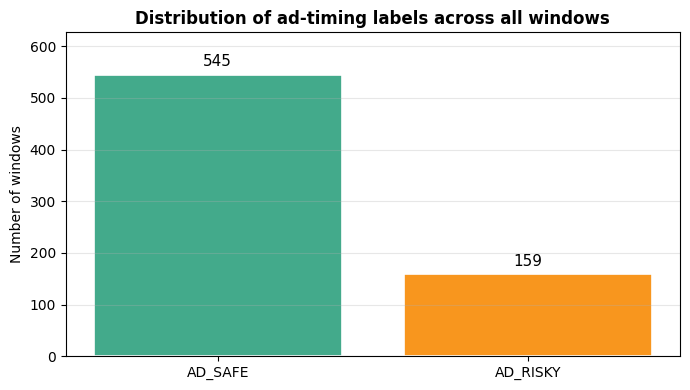

In [4]:
# ── 4. Visualise policy ───────────────────────────────────────────────────
# (a) Label distribution
fig = plot_label_distribution(scored, save_path=f"{OUTPUT_DIR}/ad_label_distribution.png")
plt.show()

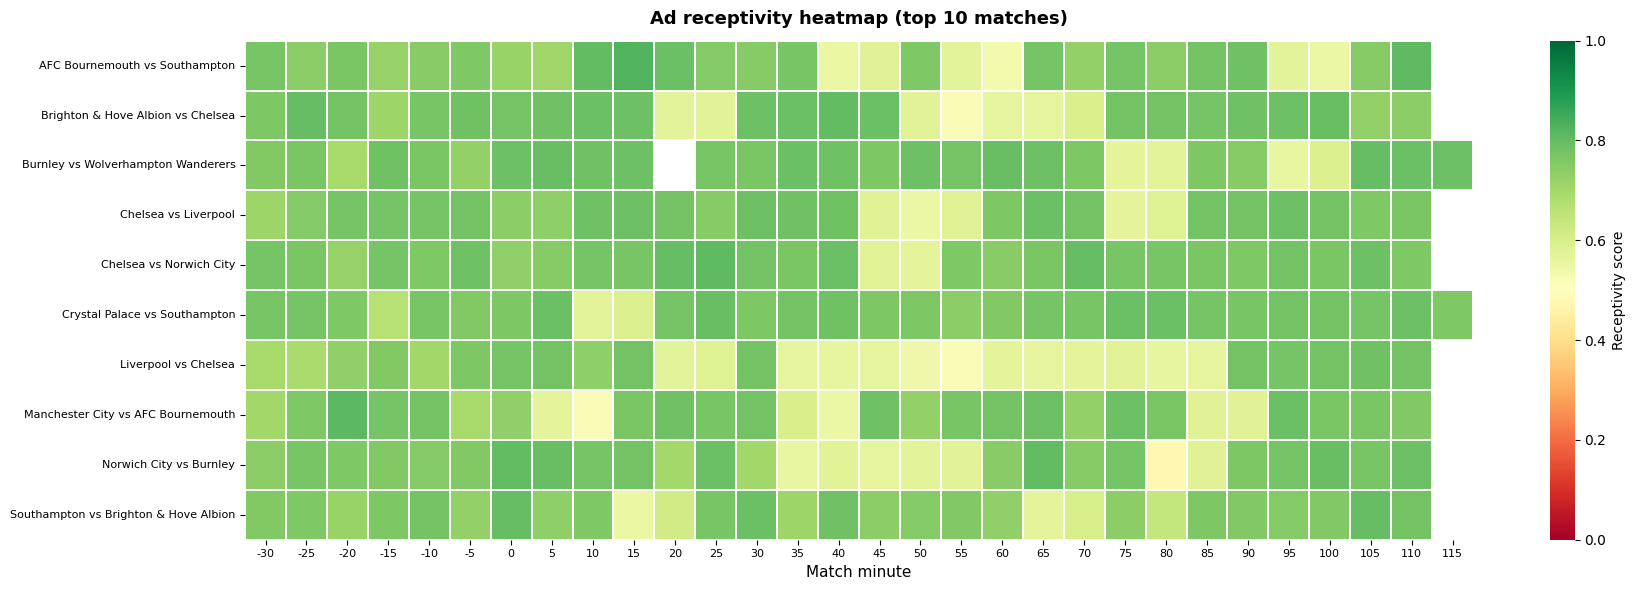

In [5]:
# (b) Receptivity heatmap across matches
fig = plot_receptivity_heatmap(scored, top_n_matches=10,
                                save_path=f"{OUTPUT_DIR}/receptivity_heatmap.png")
plt.show()

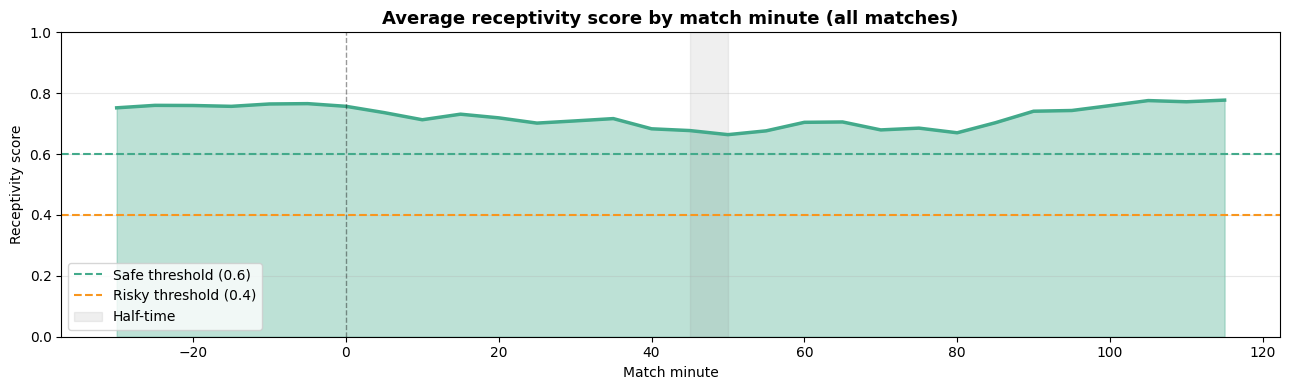

In [6]:
# (c) Receptivity over match minutes (pooled average)
rec_by_min = scored.groupby("window_5min")["receptivity_score"].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(rec_by_min.index, rec_by_min.values, alpha=0.35, color="#43aa8b")
ax.plot(rec_by_min.index, rec_by_min.values, color="#43aa8b", linewidth=2.5)
ax.axhline(SAFE_THRESHOLD,  color="#43aa8b", linewidth=1.5, linestyle="--", label=f"Safe threshold ({SAFE_THRESHOLD})")
ax.axhline(RISKY_THRESHOLD, color="#f8961e", linewidth=1.5, linestyle="--", label=f"Risky threshold ({RISKY_THRESHOLD})")
ax.axvspan(45, 50, alpha=0.12, color="grey", label="Half-time")
ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.4)
ax.set_title("Average receptivity score by match minute (all matches)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Match minute")
ax.set_ylabel("Receptivity score")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/receptivity_by_minute.png", dpi=150)
plt.show()

In [7]:
# ── 5. Recommend ad slots ─────────────────────────────────────────────────
recommended = recommend_ad_slots(scored, max_ads_per_match=4, min_gap_windows=2)

print(f"Recommended slots: {len(recommended)} across {recommended['fixture_id'].nunique()} matches")
recommended.head(10)

Recommended slots: 128 across 41 matches


,fixture_id,match,window_5min,period_label,receptivity_score,ad_label,dominant_emotion,mean_arousal,mean_valence,mean_pressure,tweet_count,high_intensity_count,recent_high_intensity
0,11867556,AFC Bournemouth vs Tottenham Hotspur,105,2nd_half,0.792065,AD_SAFE,optimism,0.519838,0.033416,0.0,1,0,0
1,11867561,Everton vs Southampton,90,2nd_half,0.747803,AD_SAFE,sadness,0.241483,-0.758019,1.0,1,0,0
2,11867561,Everton vs Southampton,100,2nd_half,0.754783,AD_SAFE,optimism,0.497342,-0.231403,0.0,5,0,0
3,11867561,Everton vs Southampton,110,2nd_half,0.761517,AD_SAFE,optimism,0.541512,-0.109394,0.0,3,0,0
4,11867566,AFC Bournemouth vs Leicester City,-30,pre_match,0.746875,AD_SAFE,optimism,0.632811,0.008167,0.0,1,0,0
5,11867566,AFC Bournemouth vs Leicester City,-20,pre_match,0.708572,AD_SAFE,optimism,0.605305,-0.246531,0.0,1,0,0
6,11867569,Liverpool vs Burnley,110,2nd_half,0.783953,AD_SAFE,optimism,0.540118,0.037949,0.0,42,0,0
7,11867572,Sheffield United vs Chelsea,25,1st_half,0.791230,AD_SAFE,optimism,0.521926,0.050950,0.0,5,0,0
8,11867572,Sheffield United vs Chelsea,40,1st_half,0.779924,AD_SAFE,joy,0.550190,0.384795,0.0,14,0,0
9,11867572,Sheffield United vs Chelsea,50,2nd_half,0.771893,AD_SAFE,joy,0.570268,0.239392,0.0,24,0,0


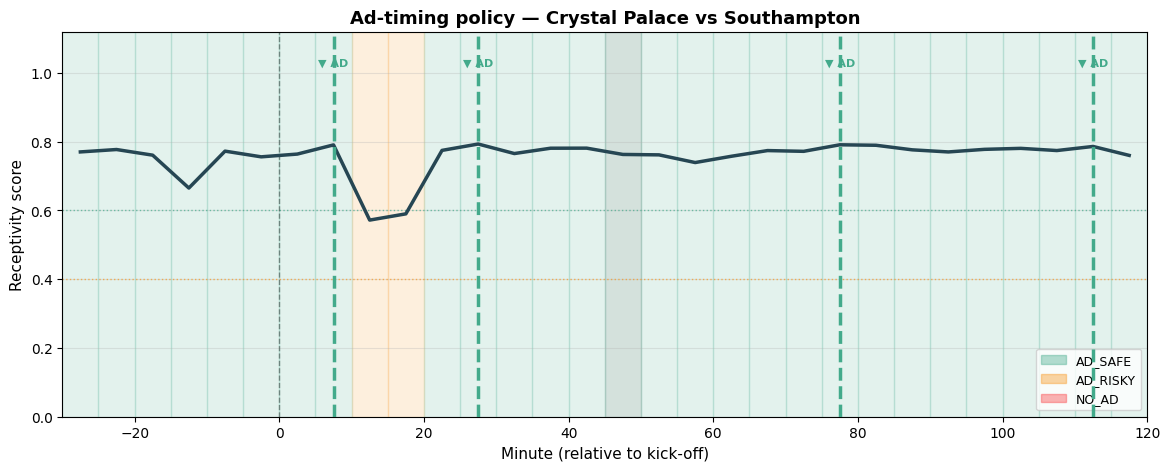

In [8]:
# Ad slots on individual match timeline
top_fixture = scored.groupby("fixture_id")["window_5min"].count().idxmax()

fig = plot_ad_slots_on_timeline(
    scored_df=scored,
    recommended_df=recommended,
    fixture_id=top_fixture,
    save_path=f"{OUTPUT_DIR}/ad_slots_example.png"
)
plt.show()

In [9]:
# ── 6. Match-level summary ────────────────────────────────────────────────
summary = summarise_policy(scored)
print(summary.sort_values("pct_safe", ascending=False).head(10).to_string(index=False))

 fixture_id                                     match  total_windows  safe_windows  risky_windows  no_ad_windows  mean_receptivity  best_receptivity  pct_safe
   11867556      AFC Bournemouth vs Tottenham Hotspur              2             2              0              0          0.783838          0.792065     100.0
   11867561                    Everton vs Southampton              5             5              0              0          0.743912          0.761517     100.0
   11867566         AFC Bournemouth vs Leicester City              3             3              0              0          0.734108          0.746875     100.0
   11867569                      Liverpool vs Burnley              1             1              0              0          0.783953          0.783953     100.0
   11867575        Wolverhampton Wanderers vs Everton              2             2              0              0          0.786596          0.788484     100.0
   11867599       Crystal Palace vs Tottenham 

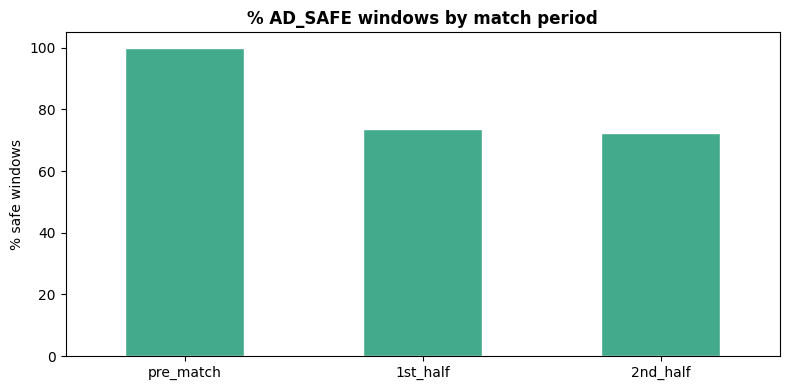

In [10]:
# % safe windows by period
if "period_label" in scored.columns:
    period_safe = scored.groupby("period_label")["ad_label"].apply(
        lambda x: (x == "AD_SAFE").mean() * 100
    ).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    period_safe.plot(kind="bar", ax=ax, color="#43aa8b", edgecolor="white")
    ax.set_title("% AD_SAFE windows by match period", fontsize=12, fontweight="bold")
    ax.set_ylabel("% safe windows")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/safe_windows_by_period.png", dpi=150)
    plt.show()

In [11]:
# ── 7. Export ─────────────────────────────────────────────────────────────
scored.to_csv(f"{OUTPUT_DIR}/scored_windows.csv", index=False)
recommended.to_csv(f"{OUTPUT_DIR}/recommended_ad_slots.csv", index=False)
summary.to_csv(f"{OUTPUT_DIR}/match_policy_summary.csv", index=False)

print("Exported:")
print(f"  {OUTPUT_DIR}/scored_windows.csv")
print(f"  {OUTPUT_DIR}/recommended_ad_slots.csv")
print(f"  {OUTPUT_DIR}/match_policy_summary.csv")

Exported:
  ../outputs/scored_windows.csv
  ../outputs/recommended_ad_slots.csv
  ../outputs/match_policy_summary.csv
